# Credit Card Fraud Detection

## Week 5 — Handling Imbalanced & Messy Real-World Data

This project focuses on detecting fraudulent credit card transactions in an imbalanced dataset.

### Objectives
- Analyze class imbalance
- Visualize the distribution of normal and fraudulent transactions
- Train a baseline machine learning model
- Handle class imbalance using SMOTE
- Compare Precision, Recall, and F1-score before and after balancing
- Understand why accuracy can be misleading for imbalanced datasets

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

## 1. Load the Dataset

The Credit Card Fraud Detection dataset is loaded into a Pandas DataFrame using Pandas. The first few rows are displayed to understand the structure of the dataset.

In [6]:
# Load the dataset

df = pd.read_csv("creditcard.csv")

# Display the first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Understand the Dataset

Before building the model, we inspect the size and structure of the dataset. This helps us understand how many transactions and features are available.

In [7]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 3. Check Missing Values and Data Types

We check for missing values and inspect the data types of all columns. This helps identify any data quality issues before training the machine learning model.

In [8]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


## 4. Check Class Distribution

The target variable is the `Class` column, where:

- `0` represents a normal transaction.
- `1` represents a fraudulent transaction.

We examine the class distribution to identify whether the dataset is imbalanced.

In [9]:
# Check the number of transactions in each class
class_counts = df["Class"].value_counts()

print("Class Distribution:")
print(class_counts)

# Calculate the percentage of each class
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("\nClass Percentages:")
print(class_percentages)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## 5. Visualize Class Distribution

The class distribution is visualized using a bar chart to clearly show the imbalance between normal and fraudulent transactions.

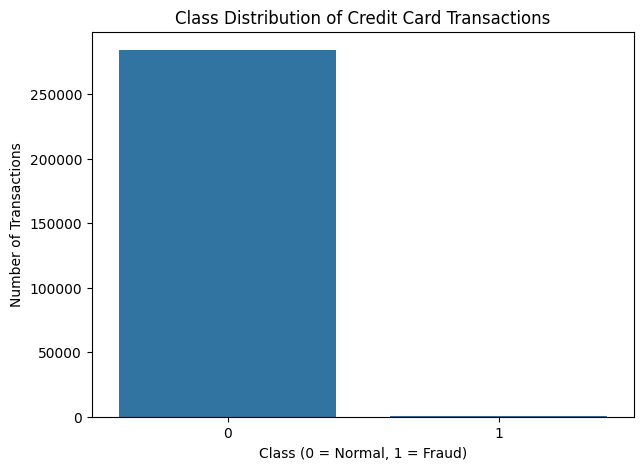

In [10]:
# Plot the class distribution

plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution of Credit Card Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

## 6. Separate Features and Target

The `Class` column is the target variable that we want to predict. All remaining columns are used as input features for the machine learning model.

In [11]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


## 7. Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets. The training set will be used to train the machine learning model, while the testing set will be used to evaluate its performance on unseen data.

We use 80% of the data for training and 20% for testing. Stratification is used to maintain the same proportion of normal and fraudulent transactions in both sets.

In [12]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 227845
Testing samples: 56962


## 8. Train the Baseline Model

A Logistic Regression model is trained on the original imbalanced training data. This baseline model will be used to compare performance before and after applying an imbalance-handling technique.

In [13]:
# Create and train the baseline Logistic Regression model

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_baseline = baseline_model.predict(X_test)

print("Baseline model training completed.")

Baseline model training completed.


c:\Users\Talal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 8.1 Scale the Features

The features in the dataset have different scales. Feature scaling helps Logistic Regression converge more effectively and improves the reliability of the baseline model.

In [14]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### 8.2 Train the Scaled Baseline Model

The Logistic Regression model is retrained using the scaled features. This helps the optimization process converge more effectively.

In [15]:
# Create the baseline Logistic Regression model

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using scaled training data
baseline_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("Scaled baseline model training completed.")

Scaled baseline model training completed.


## 9. Evaluate the Baseline Model

Precision, Recall, and F1-score are used to evaluate the baseline model.

These metrics are more informative than accuracy for fraud detection because the dataset contains a highly imbalanced target variable.

In [16]:
# Calculate baseline performance metrics

baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Baseline Model Performance")
print("-" * 30)
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-Score:  {baseline_f1:.4f}")

Baseline Model Performance
------------------------------
Precision: 0.8267
Recall:    0.6327
F1-Score:  0.7168


## Confusion Matrix — Baseline Model

The confusion matrix shows how many samples were correctly and incorrectly classified by the baseline model.

- **True Negative (TN):** Correctly predicted negative cases
- **False Positive (FP):** Negative cases incorrectly predicted as positive
- **False Negative (FN):** Positive cases incorrectly predicted as negative
- **True Positive (TP):** Correctly predicted positive cases

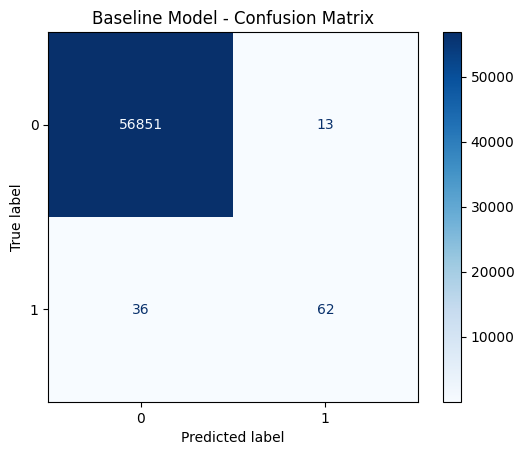

In [17]:
# Plot confusion matrix for baseline model

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    cmap="Blues"
)

plt.title("Baseline Model - Confusion Matrix")
plt.show()

## Classification Report — Baseline Model

The classification report provides detailed performance metrics for each class, including:

- **Precision:** How many predicted positive cases were actually positive.
- **Recall:** How many actual positive cases were correctly identified.
- **F1-Score:** Harmonic mean of precision and recall.
- **Support:** Number of actual samples belonging to each class.

This report helps evaluate whether the baseline model performs equally well across both classes.

In [18]:
# Generate classification report for baseline model

from sklearn.metrics import classification_report

print("Baseline Model Classification Report")
print("-" * 40)

print(classification_report(y_test, y_pred_baseline))

Baseline Model Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## Check Class Distribution

Before applying any technique to handle class imbalance, we first examine the distribution of the target classes.

If one class contains significantly more samples than the other, the dataset is considered imbalanced. This can cause the model to favor the majority class and perform poorly on the minority class.

In [19]:
# Check class distribution

class_distribution = y.value_counts()

print("Class Distribution")
print("-" * 30)
print(class_distribution)

print("\nClass Distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Class Distribution
------------------------------
Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution (%):
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


In [20]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Handle Class Imbalance Using SMOTE

The dataset is highly imbalanced, with only 0.17% of the samples belonging to the minority class.

To address this imbalance, we will use **SMOTE (Synthetic Minority Over-sampling Technique)**.

SMOTE generates synthetic samples for the minority class instead of simply duplicating existing samples.

Important:
- SMOTE will be applied **only to the training data**.
- The test data will remain unchanged so that model evaluation reflects real-world performance.

In [21]:
# Apply SMOTE to the training data

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Data:")
print(y_train.value_counts())

print("\nTraining Data After SMOTE:")
print(y_train_smote.value_counts())

Original Training Data:
Class
0    227451
1       394
Name: count, dtype: int64

Training Data After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## Train Model on SMOTE-Balanced Data

The training data is now balanced using SMOTE.

We will retrain the baseline model using the SMOTE-balanced training data while keeping the original test data unchanged.

This allows us to compare whether balancing the training data improves the model's ability to detect the minority class.

In [23]:
# Train the model using SMOTE-balanced training data

from sklearn.linear_model import LogisticRegression

smote_model = LogisticRegression(max_iter=1000, random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

# Make predictions on the original test data
y_pred_smote = smote_model.predict(X_test)

print("SMOTE model training completed.")

SMOTE model training completed.


c:\Users\Talal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluate SMOTE Model Performance

The SMOTE-trained model is evaluated on the original test set.

We will calculate Precision, Recall, and F1-Score and compare these results with the baseline model.

These metrics are especially important for imbalanced classification because accuracy alone can be misleading.

In [24]:
# Calculate SMOTE model performance metrics

smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)

print("SMOTE Model Performance")
print("-" * 30)
print(f"Precision: {smote_precision:.4f}")
print(f"Recall:    {smote_recall:.4f}")
print(f"F1-Score:  {smote_f1:.4f}")

SMOTE Model Performance
------------------------------
Precision: 0.1257
Recall:    0.8980
F1-Score:  0.2206


## Baseline vs SMOTE Performance Comparison

The baseline model and SMOTE model are compared using Precision, Recall, and F1-Score.

The main objective is to determine whether SMOTE improves the detection of the minority class.

For fraud detection, Recall is particularly important because missing an actual fraud case can be more costly than incorrectly flagging a legitimate transaction.

In [25]:
# Compare Baseline and SMOTE model performance

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline", "SMOTE"],
    "Precision": [baseline_precision, smote_precision],
    "Recall": [baseline_recall, smote_recall],
    "F1-Score": [baseline_f1, smote_f1]
})

print(comparison.round(4))

      Model  Precision  Recall  F1-Score
0  Baseline     0.8267  0.6327    0.7168
1     SMOTE     0.1257  0.8980    0.2206


## Baseline vs SMOTE — Performance Visualization

A bar chart is used to visually compare the Precision, Recall, and F1-Score of the baseline and SMOTE models.

This visualization makes it easier to understand the impact of handling class imbalance using SMOTE.

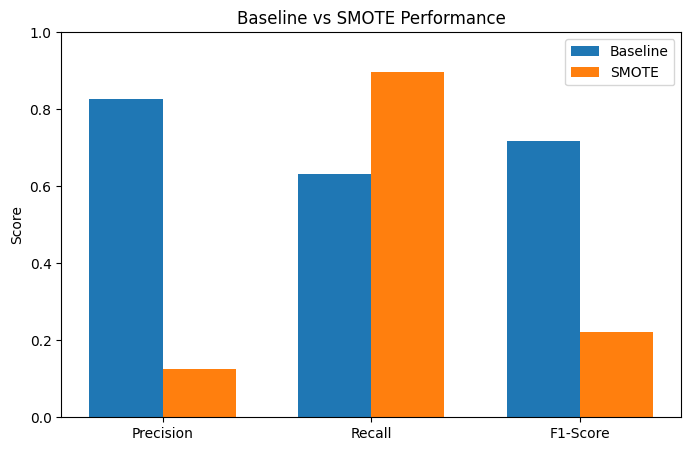

In [26]:
# Visualize model performance comparison

import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1-Score"]

baseline_scores = [
    baseline_precision,
    baseline_recall,
    baseline_f1
]

smote_scores = [
    smote_precision,
    smote_recall,
    smote_f1
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width / 2 for i in x],
    baseline_scores,
    width,
    label="Baseline"
)

plt.bar(
    [i + width / 2 for i in x],
    smote_scores,
    width,
    label="SMOTE"
)

plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.title("Baseline vs SMOTE Performance")
plt.ylim(0, 1)
plt.legend()
plt.show()

## Why Accuracy Is Misleading for Imbalanced Data

Accuracy can be misleading when the dataset is highly imbalanced.

In this dataset, 99.83% of transactions belong to Class 0, while only 0.17% belong to Class 1. Therefore, a model could achieve very high accuracy simply by predicting most transactions as Class 0.

However, this would result in poor detection of the minority class, which represents fraudulent transactions.

For this reason, Precision, Recall, and F1-Score are more informative metrics for this problem. Recall is especially important because it measures how many actual fraudulent transactions are correctly detected.

In [27]:
# Compare accuracy of both models

from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
smote_accuracy = accuracy_score(y_test, y_pred_smote)

print("Accuracy Comparison")
print("-" * 30)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"SMOTE Accuracy:    {smote_accuracy:.4f}")

Accuracy Comparison
------------------------------
Baseline Accuracy: 0.9991
SMOTE Accuracy:    0.9891


## Conclusion

The Credit Card Fraud Detection dataset was highly imbalanced, with Class 0 representing 99.83% of the data and Class 1 representing only 0.17%.

The baseline Logistic Regression model was evaluated using Precision, Recall, and F1-Score. SMOTE was then applied only to the training data to balance the two classes.

After applying SMOTE, the model achieved a Recall of **0.8980**, meaning it was able to identify approximately 89.80% of the actual minority-class cases.

Although the SMOTE model had lower Precision (**0.1257**), it significantly improved the detection of the minority class. The F1-Score was **0.2206**, providing a better balance between Precision and Recall than relying on accuracy alone.

Overall, SMOTE helped the model become more effective at detecting the minority class. This demonstrates why class imbalance should be addressed in fraud detection problems and why Precision, Recall, and F1-Score are more informative than accuracy alone.